### **1.Setup**


In [45]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from IPython.display import display
import math

train_path=os.path.join("..","data","raw","train.csv")


### **2.Loading Data and First Look**

#### **2.1. Overall First Look**

In [26]:
df_raw= pd.read_csv(train_path,index_col="ID",sep=",")
print(f"Rows:{df_raw.shape[0]:,} | Columns:{df_raw.shape[1]}")
df_raw.head()

Rows:6,534 | Columns:38


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,...,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,random_noise
ID,,,,,,,,,,,,,,,,,,,,,
10000000,558.11,510.90,453.75,104.36,0.0,0.0,57.15,153.099911,4.0,1.0,...,858.30,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,-0.660448
10000001,978.80,830.02,795.77,183.03,0.0,0.0,34.25,472.943134,32.0,1.0,...,2500.68,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,0.924510
10000002,10.33,12.00,8.40,1.93,0.0,0.0,3.60,6.097485,1.0,1.0,...,7899.80,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,-0.258730
10000003,856.83,696.61,696.61,160.22,0.0,0.0,0.00,408.167275,9.0,1.0,...,270.33,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,1.448402
10000004,1616.10,1488.85,1313.90,302.20,0.0,0.0,174.95,485.401864,33.0,1.0,...,2062.50,122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,-1.058890


In [27]:
#df_raw.info() shows the type of each column
df_raw.info()

<class 'pandas.DataFrame'>
Index: 6534 entries, 10000000 to 10007674
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Total a Pagar                   6469 non-null   float64
 1   Total Bruto                     6469 non-null   float64
 2   Total Liquido                   6469 non-null   float64
 3   Total Imp_                      6469 non-null   float64
 4   Total Portes                    6469 non-null   float64
 5   Total Desc_ Global              6469 non-null   float64
 6   Total Desc_ Linha               6469 non-null   float64
 7   Custo                           6469 non-null   float64
 8   N_ Detalhes                     6469 non-null   float64
 9   invoice_count_current_purchase  6469 non-null   float64
 10  repeat_purchase_90d             6534 non-null   int64  
 11  days_since_previous_purchase    5673 non-null   float64
 12  customer_tenure_days            6469 no

Purchase Date as String is a problem
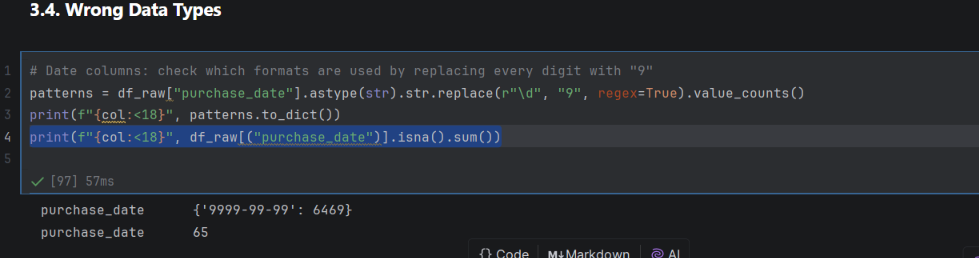

#### **2.2 Grouping the Variables**

To better organize our data we chose to group the variables by themes:

In [28]:
#Variables with special structural roles
target_col = "repeat_purchase_90d"
group_col = "customer_id"
index_col = "ID"

# Grouping by themes
var_groups = {
    "Identifier": [
        "ID",
        "customer_id"
    ],
    "Target": [
        "repeat_purchase_90d"
    ],
    "Current transaction (financial)": [
        "Total a Pagar",
        "Total Bruto",
        "Total Liquido",
        "Total Imp_",
        "Total Portes",
        "Total Desc_ Global",
        "Total Desc_ Linha",
        "Custo"
    ],
    "Current transaction (operational)": [
        "N_ Detalhes",
        "invoice_count_current_purchase"
    ],
    "Transaction context & date": [
        "purchase_date",
        "payment_type",
        "salesperson",
        "commercial_zone",
        "warehouse",
        "document_series",
        "transport_method"
    ],
    "Customer historical summary": [
        "customer_tenure_days",
        "prior_purchase_count",
        "prior_total_spend",
        "prior_mean_purchase_value",
        "prior_std_purchase_value",
        "prior_min_purchase_value",
        "prior_max_purchase_value"
    ],
    "Customer cadence & gaps": [
        "days_since_previous_purchase",
        "prior_mean_gap_days",
        "prior_std_gap_days"
    ],
    "Rolling windows (RFM)": [
        "purchase_count_30d",
        "spend_30d",
        "purchase_count_90d",
        "spend_90d",
        "purchase_count_180d",
        "spend_180d",
        "purchase_count_365d",
        "spend_365d"
    ],
    "Synthetic / Control": [
        "random_noise"
    ]
}
pd.DataFrame(
    [(group, len(cols), ", ".join(cols)) for group, cols in var_groups.items()], columns=["Group", "# vars", "Variables"])

,Group,# vars,Variables
0,Identifier,2,"ID, customer_id"
1,Target,1,repeat_purchase_90d
2,Current transaction (financial),8,"Total a Pagar, Total Bruto, Total Liquido, Tot..."
3,Current transaction (operational),2,"N_ Detalhes, invoice_count_current_purchase"
4,Transaction context & date,7,"purchase_date, payment_type, salesperson, comm..."
5,Customer historical summary,7,"customer_tenure_days, prior_purchase_count, pr..."
6,Customer cadence & gaps,3,"days_since_previous_purchase, prior_mean_gap_d..."
7,Rolling windows (RFM),8,"purchase_count_30d, spend_30d, purchase_count_..."
8,Synthetic / Control,1,random_noise


###  **3. Data Quality Assessment**

  Before changing anything, we first diagnose the problems.

#### **3.1.Duplicates**

In [29]:
n_dup_rows=df_raw.duplicated().sum()  #rows that are 100% identical
n_dup_ids=df_raw["customer_id"].duplicated().sum() #repeated member IDs
n_client_ids= df_raw["customer_id"].nunique()
print(f"Fully duplicated rows : {n_dup_rows}")
print(f"Duplicated client_id  : {n_dup_ids}")
print(f"Number of clients : {n_client_ids}")
print(f"Number of receipts/clients: {(n_dup_ids/n_client_ids).round(2)}")

Fully duplicated rows : 10
Duplicated client_id  : 5924
Number of clients : 610
Number of receipts/clients: 9.71


From this, we can conclude that there are no fully duplicated rows, ensuring that no records were duplicated due to input errors. We can also conclude that there are 6,534 records distributed across only 610 unique clients. This yields an average of approximately 9.7 transactions per client, validating the robustness of our database to feed a predictive model for 90-day repeat purchases.

#### **3.2.Missing Values**

In [30]:
missing_values=(df_raw.isna().sum().to_frame("n_missing").assign(percentage=lambda x: (x["n_missing"]*100/len(df_raw))).query("n_missing>0").sort_values("percentage", ascending=False))
missing_values

,n_missing,percentage
prior_std_gap_days,1478,22.620141
prior_mean_gap_days,1308,20.018365
prior_std_purchase_value,1113,17.033976
prior_mean_purchase_value,862,13.192531
days_since_previous_purchase,861,13.177227
prior_max_purchase_value,668,10.223447
prior_min_purchase_value,668,10.223447
transport_method,261,3.994490
warehouse,260,3.979186
payment_type,260,3.979186


Identificamos que todas as colunas à exceção da coluna ID têm missing values.Há uma consistência em todas as colunas que é a ausência de 65 linhas. Verificamos tmb que há colunas com **pelo menos 20% de MVs**. Pode fazer sentido, caso haja colunas com forte correlação com estas, dropar as colunas.

In [31]:
row_missing_percentage = pd.DataFrame({
    'customer_id': df_raw['customer_id'],
    'n_missing': df_raw.isna().sum(axis=1),
    'pct_missing': (df_raw.isna().sum(axis=1) * 100) / df_raw.shape[1]})

row_missing_percentage = (
    row_missing_percentage
    .set_index("customer_id")
    .query("n_missing > 19")
    .sort_values("n_missing", ascending=False))

print(f"There are {row_missing_percentage.shape[0]} rows with at least 50% of missing values")
row_missing_percentage


There are 65 rows with at least 50% of missing values


,n_missing,pct_missing
customer_id,,
755628,36,94.736842
755628,36,94.736842
427118,36,94.736842
508217,36,94.736842
427118,36,94.736842
...,...,...
151492,36,94.736842
230585,36,94.736842
902830,36,94.736842


Procurámos também saber a percentagem de Missing Values por Linha para avaliar a percentagem de informação que cada linha nos pode dar. Entendemos que existem 65 linhas com percentagem de Missing Values maior que 50% e por isso **consideramos descartáveis por não nos dar informações suficientes**.

#### **3.3. Inconsistent Categories**

In [32]:
cat_cols = df_raw.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
for col in cat_cols:
    print(f"{col:<10} -> {df_raw[col].nunique()} distinct values")

payment_type -> 9 distinct values
salesperson -> 9 distinct values
commercial_zone -> 5 distinct values
transport_method -> 80 distinct values
warehouse  -> 2 distinct values
document_series -> 3 distinct values
purchase_date -> 1492 distinct values


The same category is written in many different ways. This will create us a problem in the future. Lets analyse which columns need to be trimmed.

In [33]:
df_raw["payment_type"].value_counts(dropna=False)

payment_type
Maybe Tomorrow Payment 7     4565
Maybe Tomorrow Payment 12     991
Maybe Tomorrow Payment 9      502
NaN                           260
Maybe Tomorrow Payment 10     134
Maybe Tomorrow Payment 8       40
Maybe Tomorrow Payment 2       21
Maybe Tomorrow Payment 4        9
Maybe Tomorrow Payment 11       8
Maybe Tomorrow Payment 3        4
Name: count, dtype: int64

In [34]:
df_raw[("salesperson")].value_counts(dropna=False)


salesperson
VLOOKUP Master 1    4054
VLOOKUP Master 4    1461
VLOOKUP Master 9     384
NaN                  259
VLOOKUP Master 7     201
VLOOKUP Master 2     123
VLOOKUP Master 3      30
VLOOKUP Master 6      12
VLOOKUP Master 5       7
VLOOKUP Master 8       3
Name: count, dtype: int64

In [35]:
df_raw[("commercial_zone")].value_counts(dropna=False)

commercial_zone
Decorative Dashboard Zone 4    6260
Decorative Dashboard Zone 2     151
NaN                              65
Decorative Dashboard Zone 3      56
Decorative Dashboard Zone 6       1
Decorative Dashboard Zone 7       1
Name: count, dtype: int64

Esta categoria está bem. Os 65 NaNs correspondem às linhas que iremos eventualmente apagar.

In [36]:
df_raw["transport_method"].isna().sum()
print(f"There are {df_raw["transport_method"].isna().sum()} NaNs in this category")
df_raw["transport_method"].value_counts(dropna=False)



There are 261 NaNs in this category


transport_method
Maybe Tomorrow Delivery 72    1119
Maybe Tomorrow Delivery 61     627
Maybe Tomorrow Delivery 73     445
Maybe Tomorrow Delivery 59     373
Maybe Tomorrow Delivery 80     319
                              ... 
Maybe Tomorrow Delivery 55       1
Maybe Tomorrow Delivery 58       1
Maybe Tomorrow Delivery 28       1
Maybe Tomorrow Delivery 21       1
Maybe Tomorrow Delivery 23       1
Name: count, Length: 81, dtype: int64

In [37]:
df_raw[("warehouse")].value_counts(dropna=False)


warehouse
Final Excel Warehouse 1    6253
NaN                         260
Final Excel Warehouse 3      21
Name: count, dtype: int64

In [38]:
df_raw[("document_series")].value_counts(dropna=False)

document_series
Ctrl Z Series 2    2738
Ctrl Z Series 3    1903
Ctrl Z Series 1    1828
NaN                  65
Name: count, dtype: int64

In [39]:
df_raw[("purchase_date")].value_counts(dropna=False)

purchase_date
NaN           65
2015-10-31    52
2018-08-05    46
2016-07-17    42
2015-07-12    41
              ..
2021-09-03     1
2024-01-14     1
2023-09-11     1
2022-02-18     1
2024-03-13     1
Name: count, Length: 1493, dtype: int64

#### **3.4. Wrong Data Types**

#### **3.4.1. Dates**

In [40]:
# Date columns: check which formats are used by replacing every digit with "9"
patterns = df_raw["purchase_date"].astype(str).str.replace(r"\d", "9", regex=True).value_counts()
print(f"{"date format":<18}", patterns.to_dict())
print(f"{"missing values":<18}", df_raw[("purchase_date")].isna().sum())


date format        {'9999-99-99': 6469}
missing values     65


The dates are all in the format 9999-99-99 and we identified 65 NaNs.

#### **3.5. Impossible Values**

In [41]:
df_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Total a Pagar,6469.0,925.56,1335.00,0.93,188.92,476.74,1087.67,2.229721e+04
Total Bruto,6469.0,886.15,1327.64,0.83,175.74,445.74,1036.70,2.157828e+04
Total Liquido,6469.0,773.34,1136.36,0.76,154.38,389.91,903.37,1.812781e+04
Total Imp_,6469.0,152.22,225.26,0.00,29.93,79.74,184.84,4.169400e+03
Total Portes,6469.0,1.15,5.84,0.00,0.00,0.00,0.00,1.810600e+02
Total Desc_ Global,6469.0,0.35,5.12,0.00,0.00,0.00,0.00,2.184900e+02
Total Desc_ Linha,6469.0,112.47,289.99,0.00,0.00,13.13,92.28,4.103440e+03
Custo,6469.0,328.17,519.51,0.00,49.05,152.54,396.06,7.427400e+03
N_ Detalhes,6469.0,21.52,27.71,1.00,4.00,11.00,29.00,4.230000e+02
invoice_count_current_purchase,6469.0,1.07,0.31,1.00,1.00,1.00,1.00,5.000000e+00


##### **We identified 6 Impossible Values:**

days_since_previous_purchase : It's impossible to have -4 days since previous purchase;

prior_mean_gap_days : It's impossible to have a mean of -4 days;

spend_365d : Having an anual spending of -159115.18 is considered to be an error;









##### **3.5.1 Outliers**

In [42]:
numericas = df_raw.select_dtypes(include="number").drop(columns=["customer_id", target_col])
for col in numericas.columns:
    Quartile1 = df_raw[col].quantile(0.25)
    Quartile3 = df_raw[col].quantile(0.75)
    IQR = Quartile3 - Quartile1
    Min_Fence =max(Quartile1- IQR* 1.5,0)
    Max_Fence = Quartile3 + IQR* 1.5
    print(f"{col:<30}:({Min_Fence:.2f},{Max_Fence:.2f})")


Total a Pagar                 :(0.00,2435.80)
Total Bruto                   :(0.00,2328.14)
Total Liquido                 :(0.00,2026.86)
Total Imp_                    :(0.00,417.21)
Total Portes                  :(0.00,0.00)
Total Desc_ Global            :(0.00,0.00)
Total Desc_ Linha             :(0.00,230.70)
Custo                         :(0.00,916.58)
N_ Detalhes                   :(0.00,66.50)
invoice_count_current_purchase:(1.00,1.00)
days_since_previous_purchase  :(0.00,272.00)
customer_tenure_days          :(0.00,3935.50)
prior_purchase_count          :(0.00,63.00)
prior_total_spend             :(0.00,51847.47)
prior_mean_purchase_value     :(0.00,2200.38)
prior_std_purchase_value      :(0.00,2064.89)
prior_min_purchase_value      :(0.00,383.35)
prior_max_purchase_value      :(0.00,7509.26)
prior_mean_gap_days           :(0.00,220.68)
prior_std_gap_days            :(0.00,147.46)
purchase_count_30d            :(0.00,2.50)
spend_30d                     :(0.00,845.60)
purchase_co

In [49]:

for col in numericas.columns:
    val_min=numericas[col].min()
    val_max=numericas[col].max()
    Quartile1 = df_raw[col].quantile(0.25)
    Quartile3 = df_raw[col].quantile(0.75)
    IQR = Quartile3 - Quartile1
    Min_Fence =max(Quartile1- IQR* 1.5,0)
    Max_Fence = Quartile3 + IQR* 1.5
    if (val_min<Min_Fence) or (val_max>Max_Fence):
         print(f"{col:<30} -> With Outliers")
    else:
         print(f"{col:<30} -> Without Outliers")


Total a Pagar                  -> With Outliers
Total Bruto                    -> With Outliers
Total Liquido                  -> With Outliers
Total Imp_                     -> With Outliers
Total Portes                   -> With Outliers
Total Desc_ Global             -> With Outliers
Total Desc_ Linha              -> With Outliers
Custo                          -> With Outliers
N_ Detalhes                    -> With Outliers
invoice_count_current_purchase -> With Outliers
days_since_previous_purchase   -> With Outliers
customer_tenure_days           -> Without Outliers
prior_purchase_count           -> With Outliers
prior_total_spend              -> With Outliers
prior_mean_purchase_value      -> With Outliers
prior_std_purchase_value       -> With Outliers
prior_min_purchase_value       -> With Outliers
prior_max_purchase_value       -> With Outliers
prior_mean_gap_days            -> With Outliers
prior_std_gap_days             -> With Outliers
purchase_count_30d             -> Wit

Only one column has no outliers.

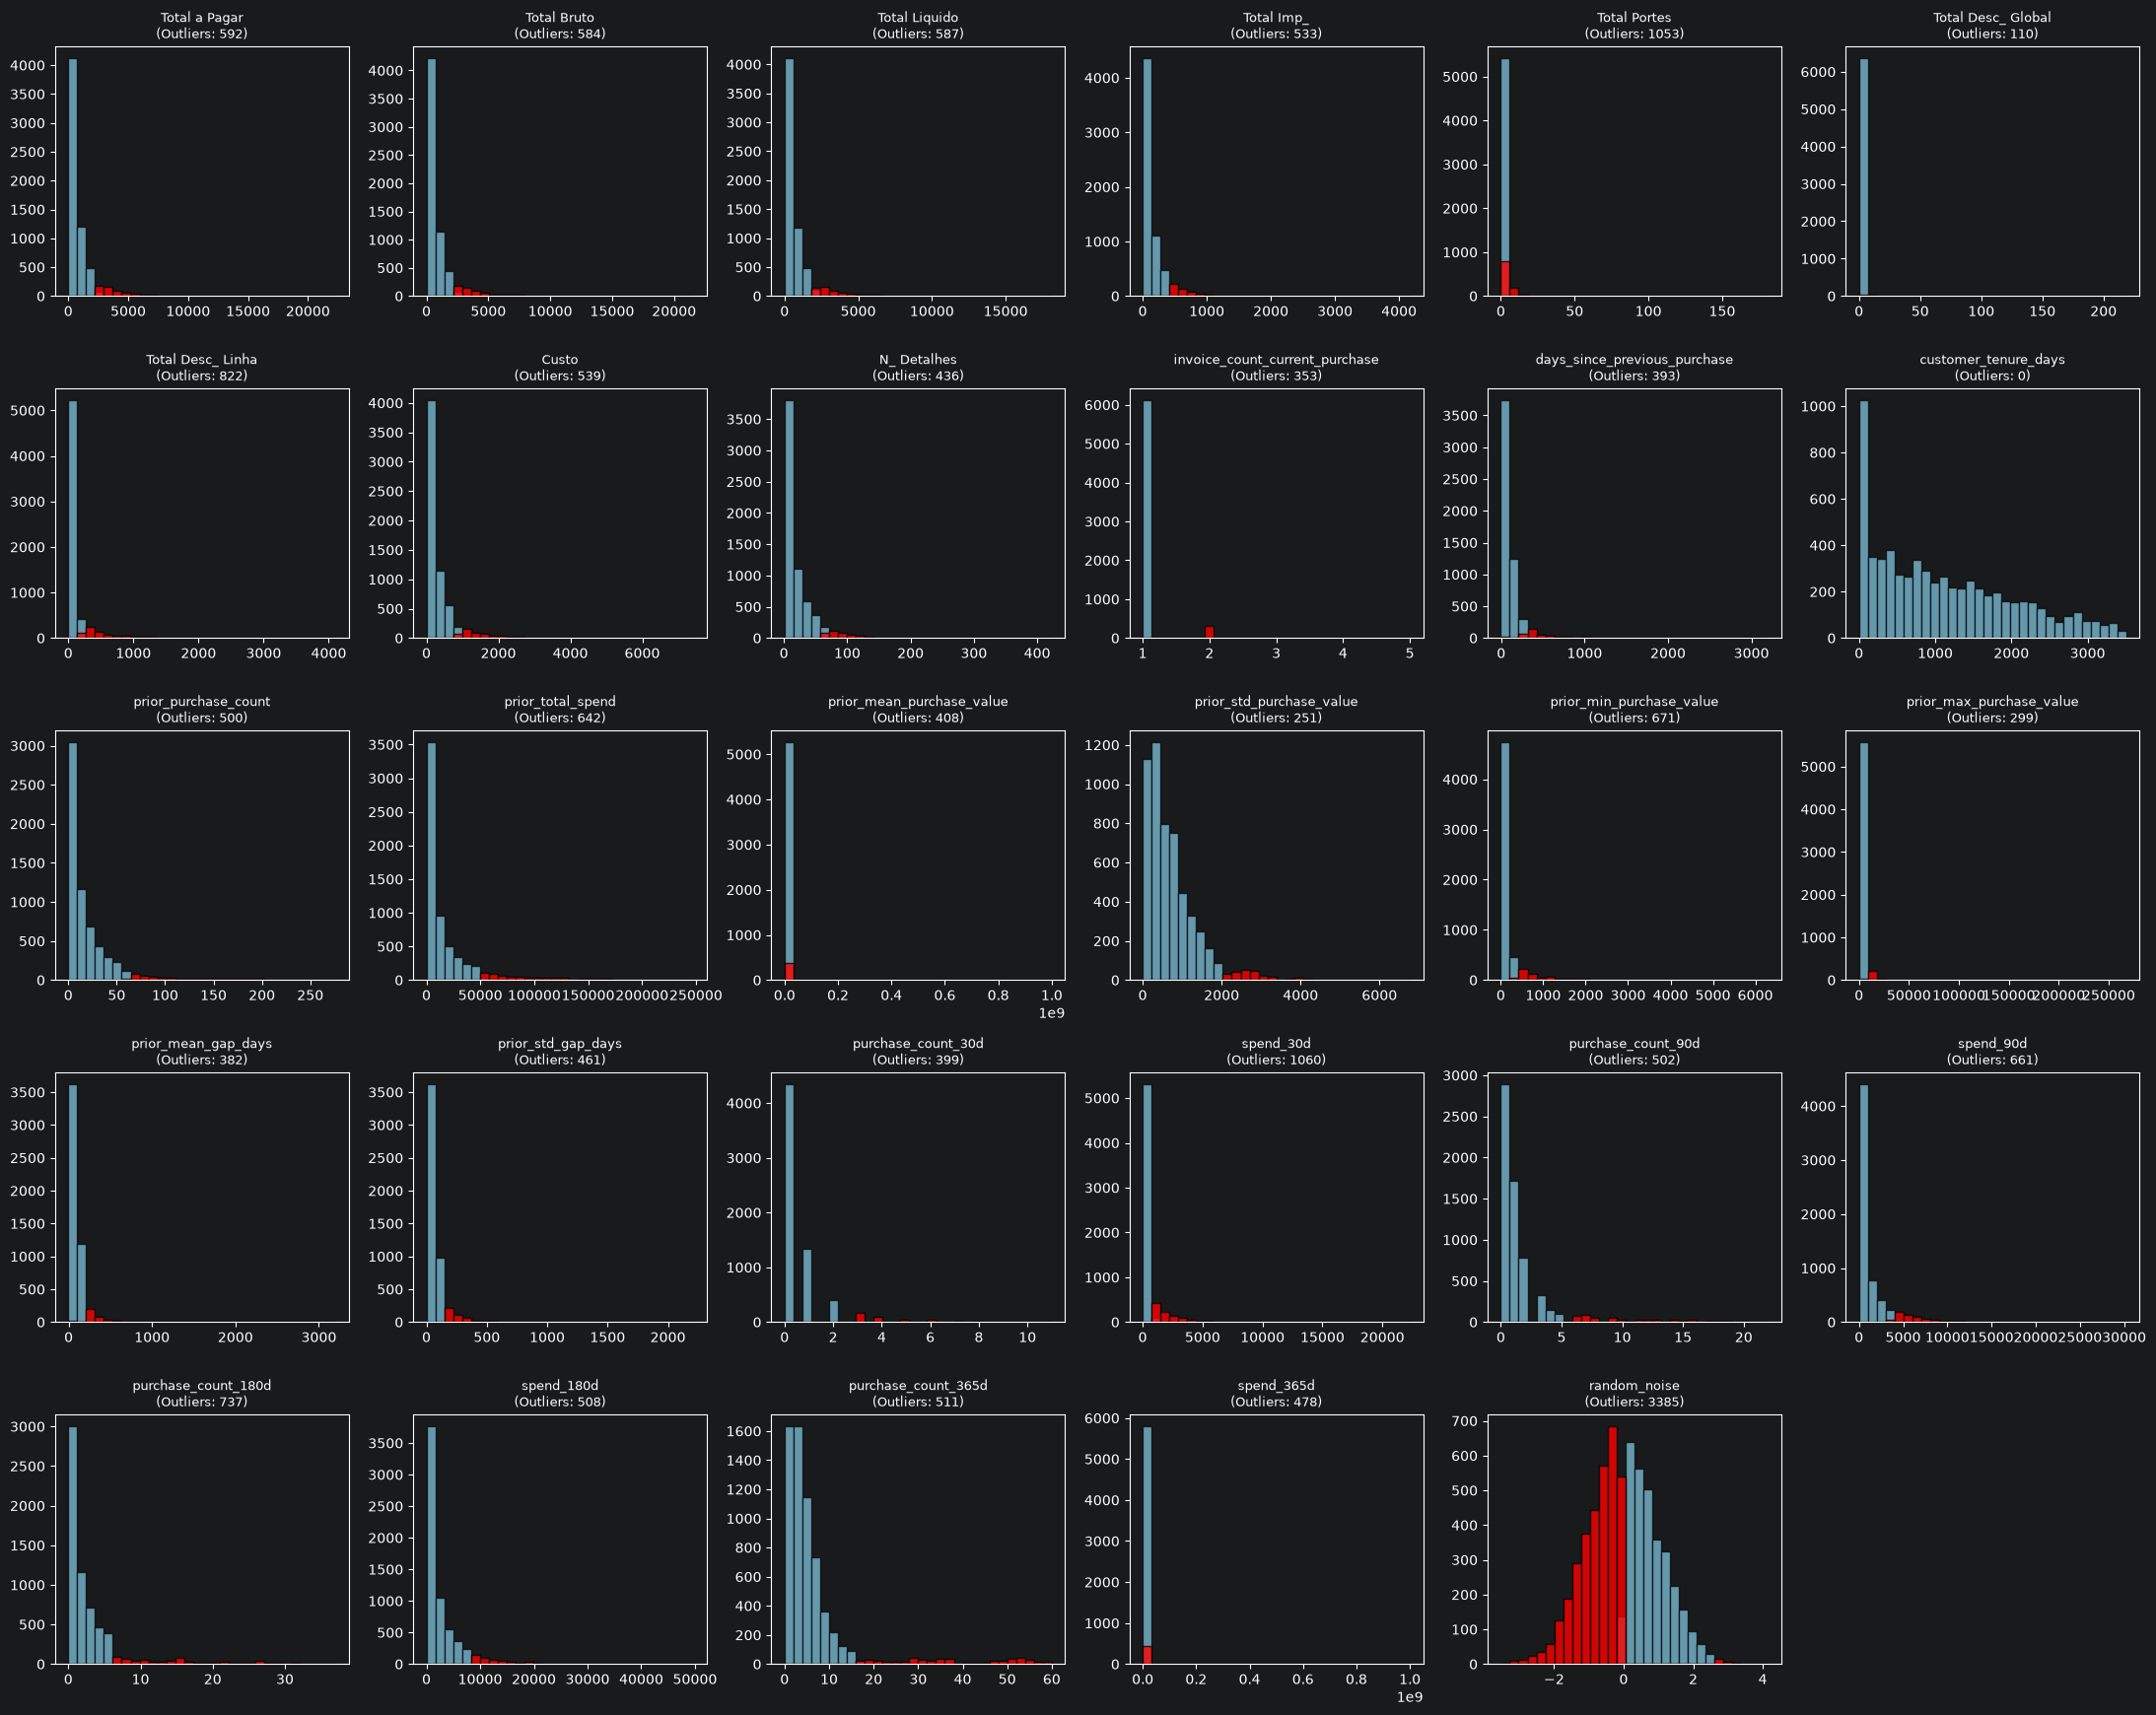

In [46]:
# 1. Selecionar as colunas numéricas
cols_num = numericas.columns # ou df_raw.select_dtypes(include=['number']).columns
n_cols = len(cols_num)

# 2. Definir a estrutura da grelha (6 colunas por linha)
ncols_grid = 6
nrows_grid = math.ceil(n_cols / ncols_grid)

# 3. Criar a figura e os subplots
fig, axes = plt.subplots(nrows=nrows_grid, ncols=ncols_grid, figsize=(22, nrows_grid * 3.5))
axes = axes.flatten()

# 4. Gerar os histogramas e colorir os outliers
for i, col in enumerate(cols_num):
    data = df_raw[col].dropna()

    # Calcular os limites do IQR para esta coluna
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    Min_Fence = max(Q1 - IQR * 1.5, 0)
    Max_Fence = Q3 + IQR * 1.5

    # Separar os dados em normais e outliers
    dados_normais = data[(data >= Min_Fence) & (data <= Max_Fence)]
    outliers_esq = data[data < Min_Fence]
    outliers_dir = data[data > Max_Fence]

    # Definir os caixotes (bins) com base em todos os dados para manter a escala correta
    bins = np.histogram_bin_edges(data, bins=30)

    # Desenhar os histogramas por partes com cores diferentes
    ax = axes[i]
    ax.hist(dados_normais, bins=bins, color='skyblue', edgecolor='black', alpha=0.7, label='Normal')
    if len(outliers_esq) > 0:
        ax.hist(outliers_esq, bins=bins, color='red', edgecolor='black', alpha=0.8, label='Outlier (Baixo)')
    if len(outliers_dir) > 0:
        ax.hist(outliers_dir, bins=bins, color='red', edgecolor='black', alpha=0.8, label='Outlier (Alto)')

    ax.set_title(f"{col}\n(Outliers: {len(outliers_esq) + len(outliers_dir)})", fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

# 5. Remover eventuais subplots vazios no final da grelha
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

A maioria dos gráficos de distribuição são Right-Skewed. Isto pode implicar ter que utilizar transformações logaritmicas para potencializar o modelo. Destaca-se das restantes colunas, a distribuição da coluna "customer_tenure_days": é a unica coluna sem outliers e com uma distribuição uniforme. Pode significar uma base de clientes com uma antiguidade bem distribuida ao longo do tempo

Lets take a deeper look to some graphs:

Nº of outliers: 478


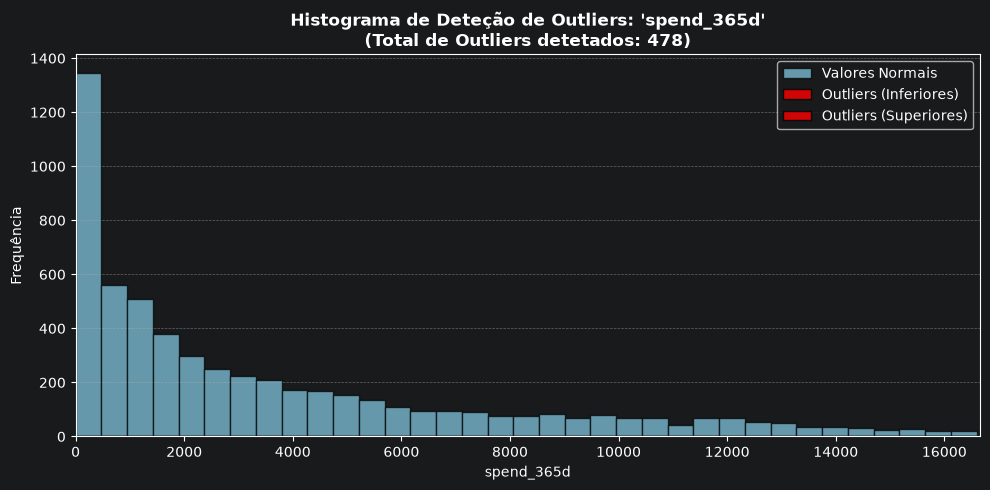

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# ALTERE APENAS O NOME DA COLUNA AQUI:
coluna_alvo = "spend_365d"
# ==========================================

# 1. Obter os dados da coluna ignorando valores nulos
data = df_raw[coluna_alvo].dropna()

# 2. Calcular os quartis e limites do IQR (Fences)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
Min_Fence = max(Q1 - IQR * 1.5, 0)
Max_Fence = Q3 + IQR * 1.5

# 3. Separar os dados em valores normais e outliers
dados_normais = data[(data >= Min_Fence) & (data <= Max_Fence)]
outliers_esq = data[data < Min_Fence]
outliers_dir = data[data > Max_Fence]
total_outliers = len(outliers_esq) + len(outliers_dir)

# 4. Criar o histograma
plt.figure(figsize=(10, 5))

# Definir os bins uniformemente com base nos dados principais para manter a consistência visual
bins = np.histogram_bin_edges(dados_normais, bins=35)

# Desenhar as partes normais (azul) e os outliers (vermelho)
plt.hist(dados_normais, bins=bins, color='skyblue', edgecolor='black', alpha=0.7, label='Valores Normais')
if len(outliers_esq) > 0:
    plt.hist(outliers_esq, bins=bins, color='red', edgecolor='black', alpha=0.8, label='Outliers (Inferiores)')
if len(outliers_dir) > 0:
    plt.hist(outliers_dir, bins=bins, color='red', edgecolor='black', alpha=0.8, label='Outliers (Superiores)')

# 5. Controlar o zoom do Eixo X (terminando de forma limpa no 3º Quartil ou logo acima)
plt.xlim(0, Max_Fence)

# 6. Formatação do gráfico
plt.title(f"Histograma de Deteção de Outliers: '{coluna_alvo}'\n(Total de Outliers detetados: {total_outliers})", fontsize=12, fontweight='bold')
plt.xlabel(coluna_alvo, fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
(df_raw["spend_365d"]>17000).sum()
print(f"Nº of outliers: {len(outliers_esq) + len(outliers_dir)}")

plt.tight_layout()
plt.show()

Here is the distribution of the column Spend_365d